***Telecom Customer Churn — Exploratory Analysis & Insight***

Role: Data Exploration Lead (Terhemba Jason Ierve)




SCOPE OF THIS SCRIPT

This script covers exploratory analysis, visualisation, churn pattern
identification, and insight generation.

In [1]:
#Import the libraries

import pandas as pd # pandas library for data manipulation
import numpy as np # numpy library for numerical operations
import matplotlib.pyplot as plt # matplotlib.pyplot for plotting
import seaborn as sns # seaborn for enhanced data visualizations

sns.set_style("whitegrid") # Set the seaborn style to 'whitegrid' for better aesthetics
plt.rcParams["figure.dpi"] = 110 # Set the default figure resolution for matplotlib plots
RANDOM_STATE = 42 # Define a random state for reproducibility in experiments
pd.set_option("display.max_columns", None) # Configure pandas to display all columns of a DataFrame

In [2]:
# Load the raw dataset exactly as received — no changes yet.
df = pd.read_csv("/content/Customer_churn.csv")

INITIAL INSPECTION

In [3]:
print("Shape:", df.shape) # Print the shape (number of rows, number of columns) of the DataFrame

Shape: (7043, 21)


In [4]:
df.head(10) # Display the first 10 rows of the DataFrame to get a quick overview of the data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [5]:
df.info() # Display a concise summary of the DataFrame, including data types, non-null values, and memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum() # Calculate the sum of null values for each column in the DataFrame

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
df.dtypes # Display the data type of each column in the DataFrame

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [8]:
# Assign Columns and Create a pandas DataFrame to store the data dictionary.(Column Name, Category, Description)

data_dictionary = pd.DataFrame([
    ("customerID", "Identifier", "Unique customer reference. Not a predictive feature — must be excluded from modeling."),
    ("gender", "Demographic", "Male / Female"),
    ("SeniorCitizen", "Demographic", "1 = senior citizen, 0 = not"),
    ("Partner", "Demographic", "Has a partner: Yes/No"),
    ("Dependents", "Demographic", "Has dependents: Yes/No"),
    ("tenure", "Account", "Months the customer has stayed with the company"),
    ("PhoneService", "Service", "Has phone service: Yes/No"),
    ("MultipleLines", "Service", "Has multiple phone lines: Yes/No/No phone service"),
    ("InternetService", "Service", "DSL / Fiber optic / No"),
    ("OnlineSecurity", "Service", "Yes/No/No internet service"),
    ("OnlineBackup", "Service", "Yes/No/No internet service"),
    ("DeviceProtection", "Service", "Yes/No/No internet service"),
    ("TechSupport", "Service", "Yes/No/No internet service"),
    ("StreamingTV", "Service", "Yes/No/No internet service"),
    ("StreamingMovies", "Service", "Yes/No/No internet service"),
    ("Contract", "Account", "Month-to-month / One year / Two year"),
    ("PaperlessBilling", "Account", "Yes/No"),
    ("PaymentMethod", "Account", "Electronic check / Mailed check / Bank transfer (automatic) / Credit card (automatic)"),
    ("MonthlyCharges", "Billing", "Current monthly charge amount ($)"),
    ("TotalCharges", "Billing", "Cumulative amount billed to date ($). NOTE: stored as text in the raw file, needs numeric conversion."),
    ("Churn", "Target", "Yes/No — whether the customer left. This is what we're predicting."),
], columns=["Column", "Category", "Description"])

# Display
data_dictionary

,Column,Category,Description
0,customerID,Identifier,Unique customer reference. Not a predictive fe...
1,gender,Demographic,Male / Female
2,SeniorCitizen,Demographic,"1 = senior citizen, 0 = not"
3,Partner,Demographic,Has a partner: Yes/No
4,Dependents,Demographic,Has dependents: Yes/No
5,tenure,Account,Months the customer has stayed with the company
6,PhoneService,Service,Has phone service: Yes/No
7,MultipleLines,Service,Has multiple phone lines: Yes/No/No phone service
8,InternetService,Service,DSL / Fiber optic / No
9,OnlineSecurity,Service,Yes/No/No internet service


In [9]:
# Checking for the Missing values in each column  of the dataframe

print("Missing Values", df.isnull().sum())


Missing Values customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [10]:
# Calculate the number of duplicate customerIDs in the DataFrame.

print("Duplicate Customer IDs:", df["customerID"].duplicated().sum())

Duplicate Customer IDs: 0


In [11]:
# Convert TotalCharges (object) to numeric values, coercing errors to NaN.

bad_total_charges = df[pd.to_numeric(df["TotalCharges"], errors="coerce").isnull()]
print("Rows where TotalCharges is not a valid number:", len(bad_total_charges))
bad_total_charges[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Rows where TotalCharges is not a valid number: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [12]:
# Are these malformed rows random, or is there a pattern?

print("All 11 problem rows have tenure == 0:", (bad_total_charges["tenure"] == 0).all())

All 11 problem rows have tenure == 0: True


In [13]:
# Quick sanity check on categorical value sets — flag anything unexpected

for col in ["gender", "SeniorCitizen", "Contract", "InternetService", "PaymentMethod", "Churn"]:
    print(f"{col}: {sorted(df[col].unique())}")


gender: ['Female', 'Male']
SeniorCitizen: [np.int64(0), np.int64(1)]
Contract: ['Month-to-month', 'One year', 'Two year']
InternetService: ['DSL', 'Fiber optic', 'No']
PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
Churn: ['No', 'Yes']


In [14]:
# Data Preparation for EDA and Overall Churn Rate Calculation

df_eda = df.copy() #Copy of the df

df_eda["TotalCharges"] = pd.to_numeric(df_eda["TotalCharges"], errors="coerce").fillna(0)

TARGET = "Churn" #Target Variable
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"] #Numerical columns only
categorical_cols = [c for c in df_eda.columns if c not in numeric_cols + ["customerID", TARGET]] #Categorical columns and Target Variable only.

churn_rate = (df_eda[TARGET] == "Yes").mean() #Calculate te overall churn rate in the dataset.

print(f"Overall churn rate: {churn_rate*100:.1f}%")

Overall churn rate: 26.5%


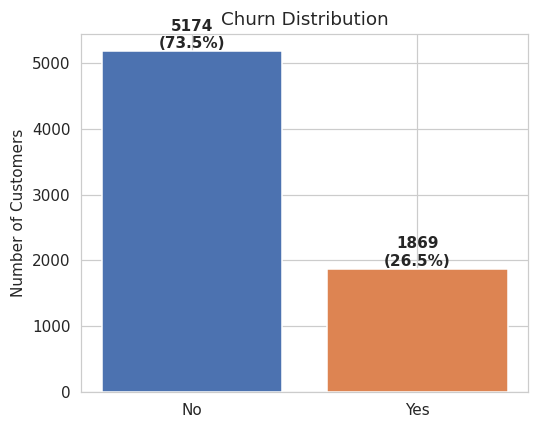

In [15]:
# Target Variable Distribution (Churn)

churn_counts = df_eda[TARGET].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(churn_counts.index, churn_counts.values, color=["#4C72B0", "#DD8452"])
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 50, f"{v}\n({v/len(df_eda)*100:.1f}%)", ha="center", fontweight="bold")
ax.set_title("Churn Distribution")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()

# Target Variable Distribution (Churn)

This cell visualizes the distribution of the target variable, `Churn`, to understand the class imbalance in the dataset. This is crucial for evaluating model performance later on, as highly imbalanced datasets can mislead standard accuracy metrics.


**Insight from the plot:** The visualization clearly shows the class imbalance, with a significantly larger number of customers who did not churn (`No`) compared to those who did (`Yes`). Specifically, approximately 73.5% of customers did not churn, while 26.5% did. This imbalance needs to be considered during model training to avoid biased predictions.

In [16]:
# Ranking Categorical Features by Churn Rate Spread

def churn_rate_by_category(df, col): # Helper function to cal churn rate for each cat in a col.
    return df.groupby(col)[TARGET].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending=False)

category_impact = {col: churn_rate_by_category(df_eda, col).max() - churn_rate_by_category(df_eda, col).min()
                    for col in categorical_cols}
impact_ranked = pd.Series(category_impact).sort_values(ascending=False)
impact_ranked.round(1)

,0
Contract,39.9
InternetService,34.5
OnlineSecurity,34.4
TechSupport,34.2
OnlineBackup,32.5
DeviceProtection,31.7
PaymentMethod,30.0
StreamingMovies,26.3
StreamingTV,26.1
SeniorCitizen,18.1


### Ranking Categorical Features by Churn Rate Spread

This cell aims to identify which categorical features are most 'discriminating' in terms of churn. A feature is considered more discriminating if the churn rate varies significantly across its different categories. This helps in understanding which features have the strongest relationship with customer churn.

**Insight from the plot:** The visualization clearly shows the class imbalance, with a significantly larger number of customers who did not churn (`No`) compared to those who did (`Yes`). Specifically, approximately 73.5% of customers did not churn, while 26.5% did. This imbalance needs to be considered during model training to avoid biased predictions.

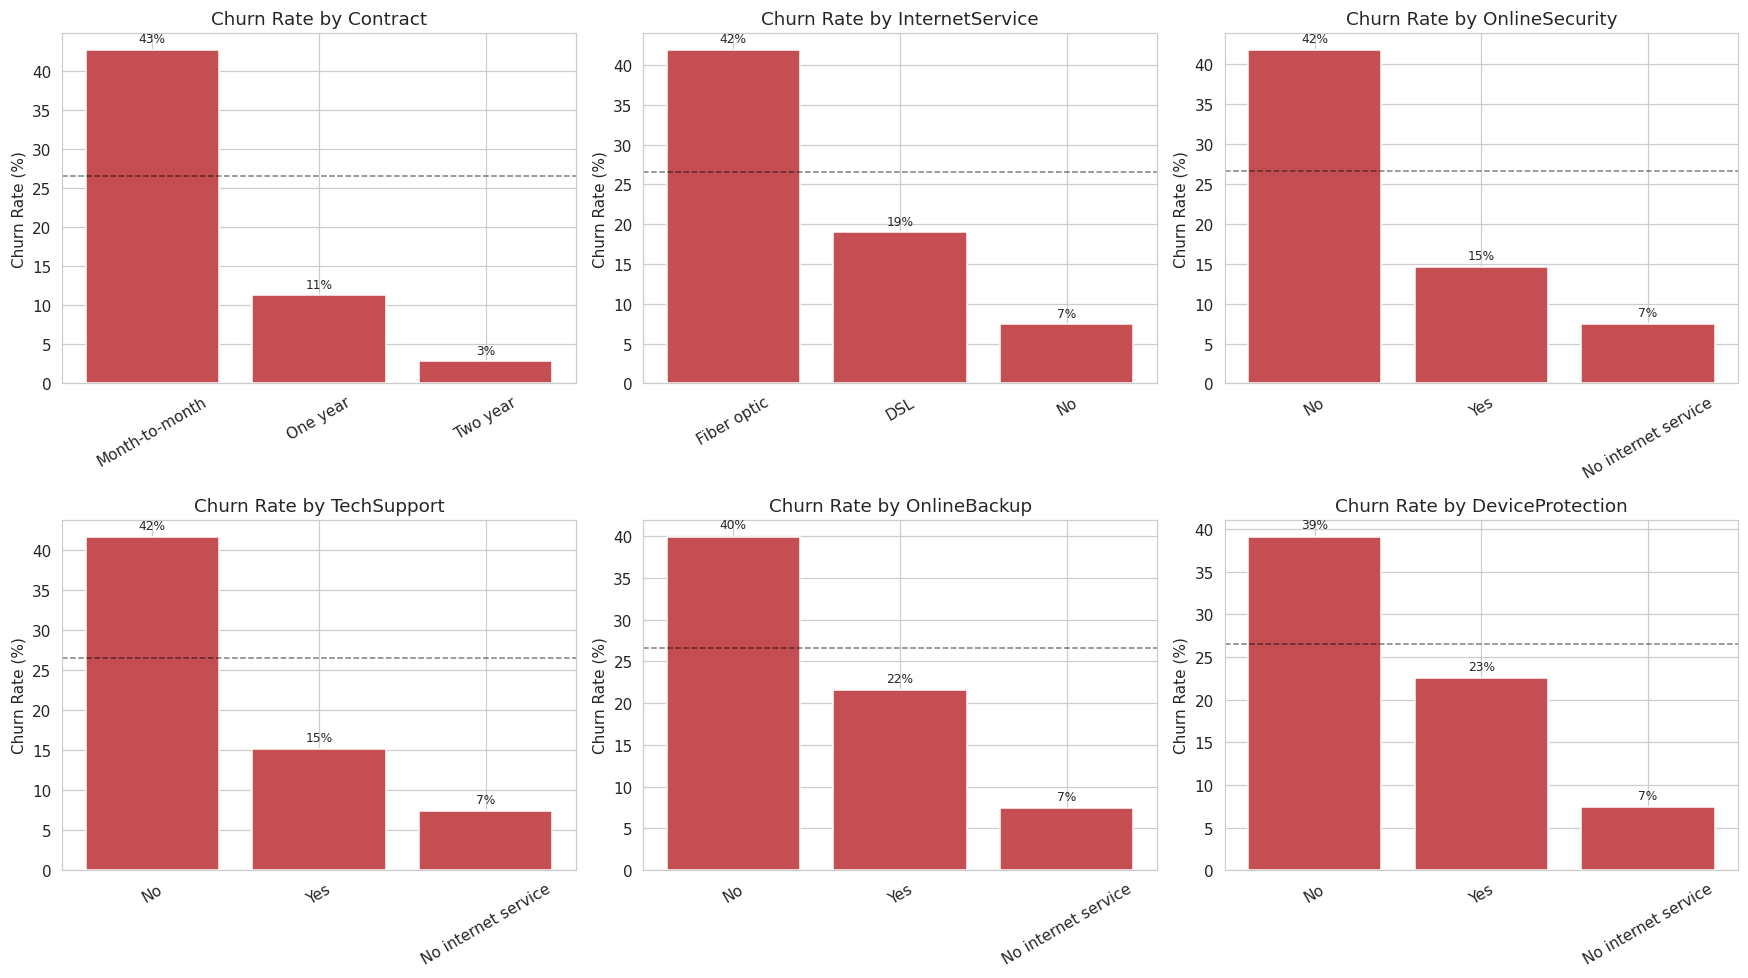

In [17]:
# Visualizing Churn Rate for Top Discriminating Categorical Features

top_features = impact_ranked.head(6).index.tolist() # Top 6 features from the 'impact_ranked' series.

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, top_features):
    rates = churn_rate_by_category(df_eda, col)
    bars = ax.bar(rates.index.astype(str), rates.values, color="#C44E52")
    ax.axhline(churn_rate * 100, color="black", linestyle="--", alpha=0.5, linewidth=1)
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate (%)")
    ax.tick_params(axis="x", rotation=30)
    for b, v in zip(bars, rates.values):
        ax.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.0f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

# Visualizing Churn Rate for Top Discriminating Categorical Features

This cell generates a series of bar plots to visually represent the churn rate across categories for the 6 most discriminating categorical features, as identified in the previous analysis. This helps in understanding the granular impact of each category within these features on customer churn.

Key Insights from the Plots:


*   Contract: Month-to-month contracts show a significantly higher churn rate (around 43%) compared to one-year (11%) and two-year (3%) contracts. This strongly suggests that longer-term contracts are a major retention factor.


*  InternetService: Customers with Fiber optic internet service have a much higher churn rate (around 42%) than those with DSL (around 19%) or no internet service (around 7%). This could indicate dissatisfaction with fiber optic service or that fiber optic customers might be more tech-savvy and willing to switch providers.


*  OnlineSecurity, TechSupport, OnlineBackup, DeviceProtection: For these security and backup related services, customers who do not have the service (but do have internet) show significantly higher churn rates (e.g., ~42% for no OnlineSecurity) compared to those who do have the service (e.g., ~15% for OnlineSecurity). Customers with "No internet service" consistently have the lowest churn rates, which is expected as they are not exposed to the same issues as internet users.

These plots visually confirm the high impact of contract type and internet-related services on customer churn, providing concrete evidence for strategic interventions.

       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       38.0          64.425      1679.525
Yes      10.0          79.650       703.550


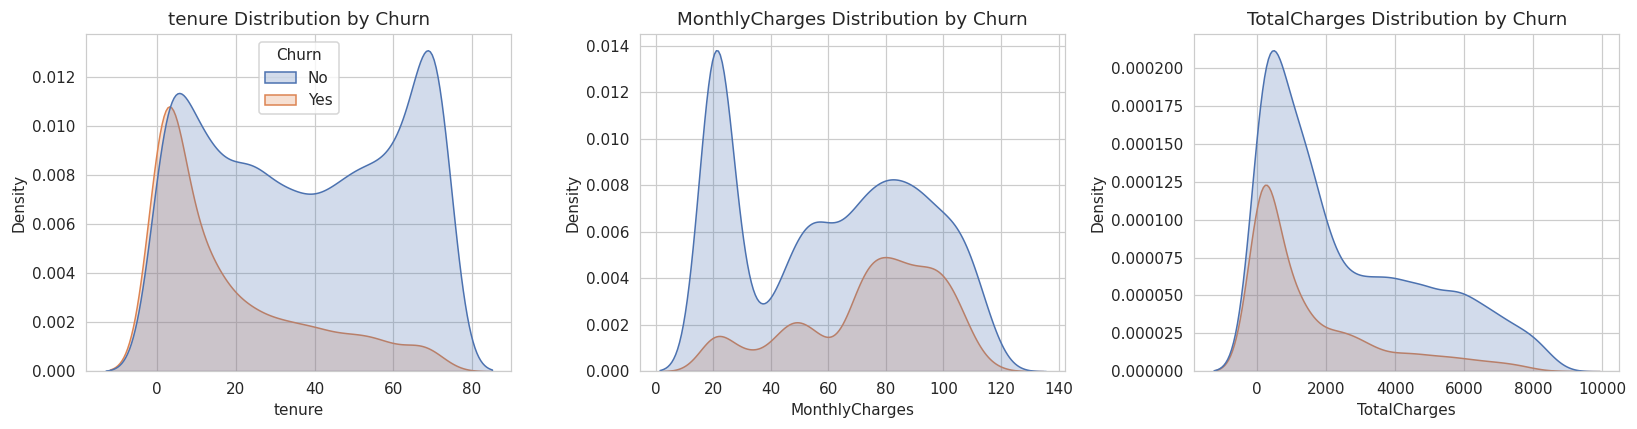

In [18]:
#Analyzing Numeric Features vs. Churn

print(df_eda.groupby(TARGET)[numeric_cols].median())
# This helps to compare the central tendency of numeric features for churned vs. non-churned customers.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(data=df_eda, x=col, hue=TARGET, fill=True,
                palette=["#4C72B0", "#DD8452"], ax=ax, legend=(col == numeric_cols[0]))
    # Generate a Kernel Density Estimate (KDE) plot for the current numeric column.
    ax.set_title(f"{col} Distribution by Churn")
plt.tight_layout()
plt.show()

### Analyzing Numeric Features vs. Churn

This cell investigates the relationship between the numeric features (`tenure`, `MonthlyCharges`, `TotalCharges`) and customer churn. It does this by first calculating the median values of these features for both churning and non-churning customers, and then visualizing their distributions using Kernel Density Estimate (KDE) plots.


**Visual Insights from KDE Plots:**
*   **`tenure`**: The KDE plot for `tenure` clearly shows that the distribution for churned customers is heavily skewed towards lower tenure values (peaking near 0-10 months), while non-churned customers have a more spread-out distribution with a peak at higher tenure values. This reinforces that shorter tenure is a strong indicator of churn.
*   **`MonthlyCharges`**: Churned customers tend to have higher `MonthlyCharges`, with their distribution peaking at higher values than non-churned customers, especially for monthly charges above ~$60.
*   **`TotalCharges`**: The distribution for churned customers is concentrated at lower `TotalCharges` values, reflecting their shorter tenure. Non-churned customers show a wider range of `TotalCharges` with a larger proportion at higher values. This further confirms that long-term, high-value customers are less likely to churn.

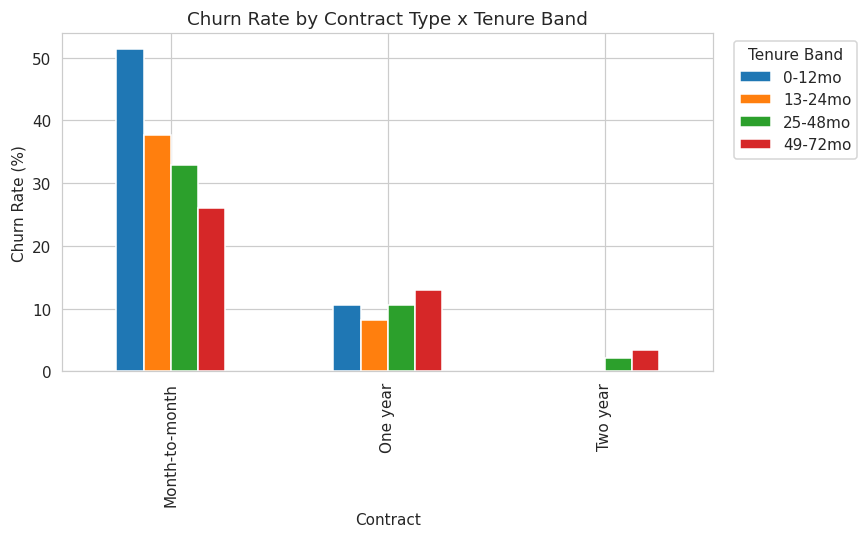

In [19]:
#Multivariate Analysis: Churn Rate by Contract Type and Tenure Band

tenure_band = pd.cut(df_eda["tenure"], bins=[0, 12, 24, 48, 72],
                      labels=["0-12mo", "13-24mo", "25-48mo", "49-72mo"])
segment_rates = df_eda.groupby(["Contract", tenure_band], observed=True)[TARGET] \
                       .apply(lambda x: (x == "Yes").mean() * 100)
fig, ax = plt.subplots(figsize=(8, 5))
segment_rates.unstack().plot(kind="bar", ax=ax)
ax.set_title("Churn Rate by Contract Type x Tenure Band")
ax.set_ylabel("Churn Rate (%)")
ax.legend(title="Tenure Band", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Multivariate Analysis: Churn Rate by Contract Type and Tenure Band

This cell performs a multivariate analysis to understand how `tenure` influences churn *within* different `Contract` types. The goal is to see if `tenure` still acts as a strong predictor of churn even when `Contract` type is considered, or if `tenure` was primarily an indicator of contract type.

**Visual Insights from the Grouped Bar Chart:**
*   **Month-to-month Contracts**: These contracts consistently show the highest churn rates across all tenure bands. The churn rate is highest in the earliest tenure band (0-12 months) at over 50% and decreases as tenure increases, but it remains significantly higher than other contract types even for long-term customers.
*   **One-year Contracts**: Churn rates for one-year contracts are much lower than month-to-month contracts. While there's some variation, they generally hover around 10-15% and are relatively stable across tenure bands.
*   **Two-year Contracts**: These contracts have the lowest churn rates, typically below 5%, and show very little churn, especially for newer tenure bands. Churn rates slightly increase for longer tenure bands, but overall, these customers are highly stable.
*   **Tenure's Independent Effect**: While `Contract` type is a dominant factor, `tenure` still shows an inverse relationship with churn *within* month-to-month contracts. Newer customers (0-12 months) on month-to-month plans are at the highest risk. This indicates that `tenure` is not merely a proxy for `Contract` type but has its own independent predictive power, especially for the most vulnerable customer segment (new, month-to-month).

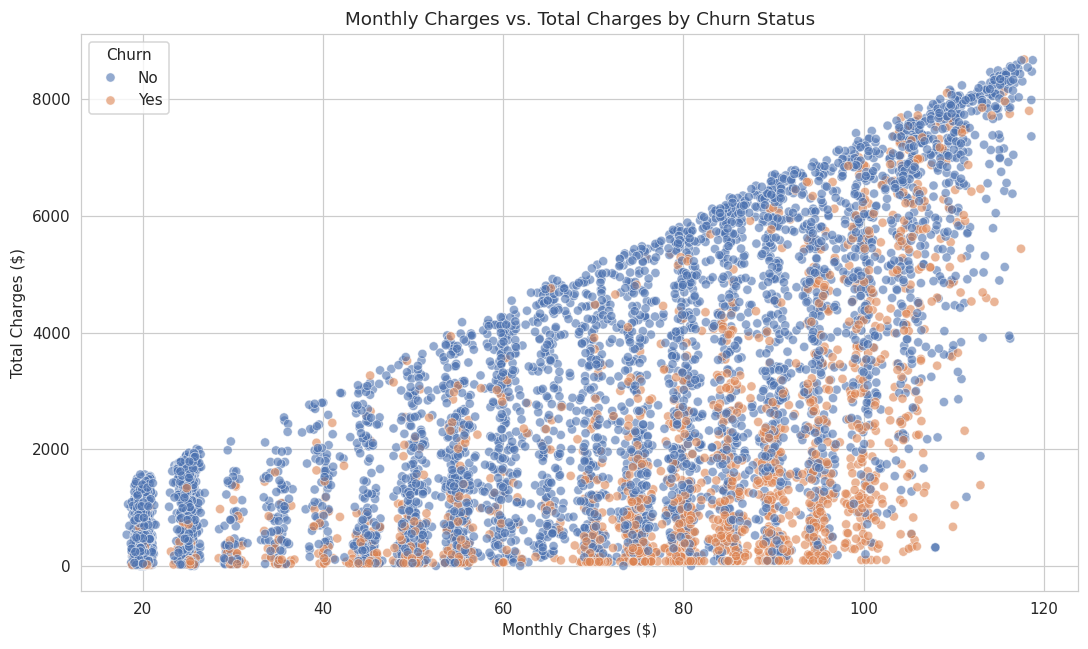

In [20]:
# Monthly Charges vs. Total Charges by Churn Status

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_eda, x="MonthlyCharges", y="TotalCharges", hue=TARGET, alpha=0.6, ax=ax, palette=["#4C72B0", "#DD8452"])
ax.set_title("Monthly Charges vs. Total Charges by Churn Status")
ax.set_xlabel("Monthly Charges ($)")
ax.set_ylabel("Total Charges ($)")
ax.legend(title="Churn")
plt.tight_layout()
plt.show()

### Monthly Charges vs. Total Charges by Churn Status

This cell generates a scatter plot to visualize the interplay between `MonthlyCharges`, `TotalCharges`, and the `Churn` status. This type of plot is excellent for revealing patterns or clusters that might indicate different customer segments with varying churn behaviors.


**Visual Insights from the Scatter Plot:**
*   **Diagonal Pattern**: There's a clear diagonal pattern, as `TotalCharges` is a cumulative sum related to `MonthlyCharges` and `tenure`. Customers with higher `MonthlyCharges` and longer `tenure` (thus higher `TotalCharges`) are generally found in the upper-right portion of the plot.
*   **Churning Customers (Orange/Red)**:
    *   A dense cluster of churning customers appears in the lower-left to mid-left areas. These customers have relatively low `TotalCharges` (indicating short `tenure`) but can have a range of `MonthlyCharges`. This reinforces the idea that newer customers are more prone to churn.
    *   The scatter plot visually confirms the earlier median analysis: churned customers tend to have lower `TotalCharges` but can have higher `MonthlyCharges` than non-churned customers, especially for new customers. This group likely represents newer customers who sign up for higher-priced plans but churn quickly.
*   **Non-Churning Customers (Blue)**:
    *   Non-churning customers are more prevalent across the spectrum, particularly in areas of higher `TotalCharges`, which corresponds to longer `tenure` and more loyalty. Even with high `MonthlyCharges`, customers with high `TotalCharges` are less likely to churn, indicating customer loyalty grows with tenure and accumulated charges.

The scatter plot reveals an interesting pattern: customers with low `TotalCharges` but relatively high `MonthlyCharges` are more likely to churn. This group likely represents newer customers with high monthly plans who churn quickly. Customers with higher `TotalCharges` (indicating longer tenure) are less likely to churn, even with high `MonthlyCharges`.

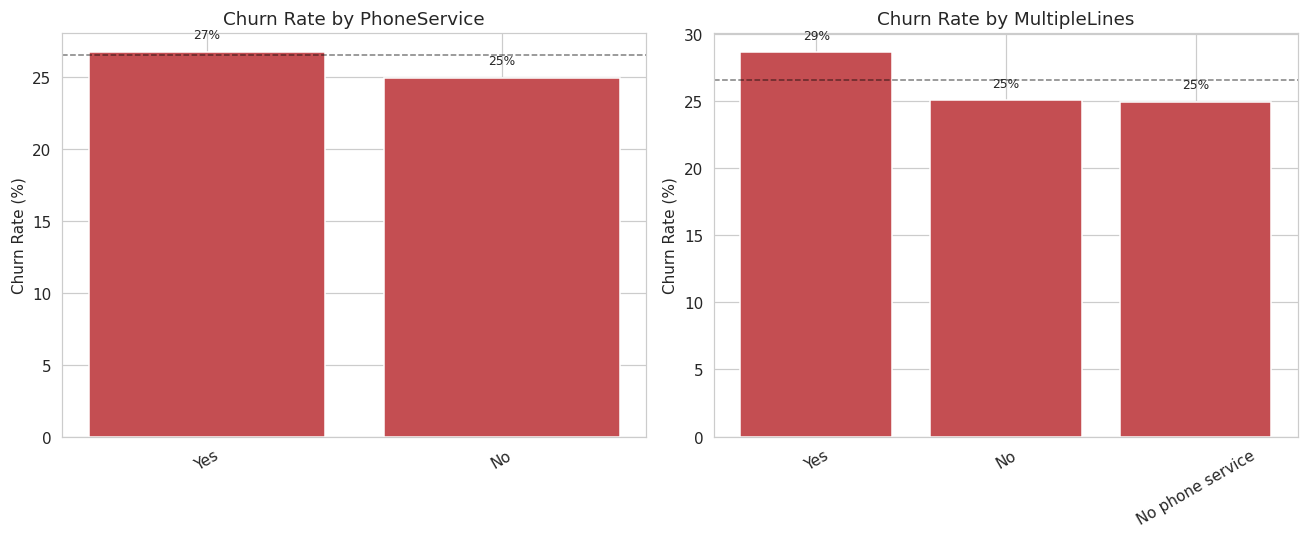

In [21]:
# Visualizing Churn Rate for Phone Service Related Features

service_features = ['PhoneService', 'MultipleLines']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes.flat, service_features):
    rates = churn_rate_by_category(df_eda, col)
    bars = ax.bar(rates.index.astype(str), rates.values, color="#C44E52")
    ax.axhline(churn_rate * 100, color="black", linestyle="--", alpha=0.5, linewidth=1)
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate (%)")
    ax.tick_params(axis="x", rotation=30)
    for b, v in zip(bars, rates.values):
        ax.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.0f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

### Visualizing Churn Rate for Phone Service Related Features

This cell generates two bar plots to examine the churn rate in relation to `PhoneService` and `MultipleLines`. These plots help determine if having phone service or multiple lines significantly impacts a customer's likelihood to churn.

**Visual Insights from the Plots:**
*   **PhoneService**: The churn rate for customers with `PhoneService` ('Yes', ~27%) is only marginally higher than those without `PhoneService` ('No', ~25%). Both are very close to the overall churn rate (approximately 26.5%). This suggests that `PhoneService` itself is not a strong predictor of churn.
*   **MultipleLines**: Customers with `MultipleLines` ('Yes', ~29%) show a slightly higher churn rate than those without `MultipleLines` ('No', ~25%) or those with `No phone service` (~25%). However, the difference is not substantial enough to categorize `MultipleLines` as a highly discriminating feature for churn.

Overall, these plots indicate that phone service features (`PhoneService` and `MultipleLines`) have a relatively low impact on customer churn compared to other factors observed earlier (like `Contract` type or `InternetService`). The churn rates are largely consistent across the categories within these features, hovering around the average.

From these plots, we can observe that having a phone service or multiple lines does not significantly impact churn rate compared to other features like contract type or internet service. The churn rates are relatively consistent across categories for these features, hovering around the overall churn rate.

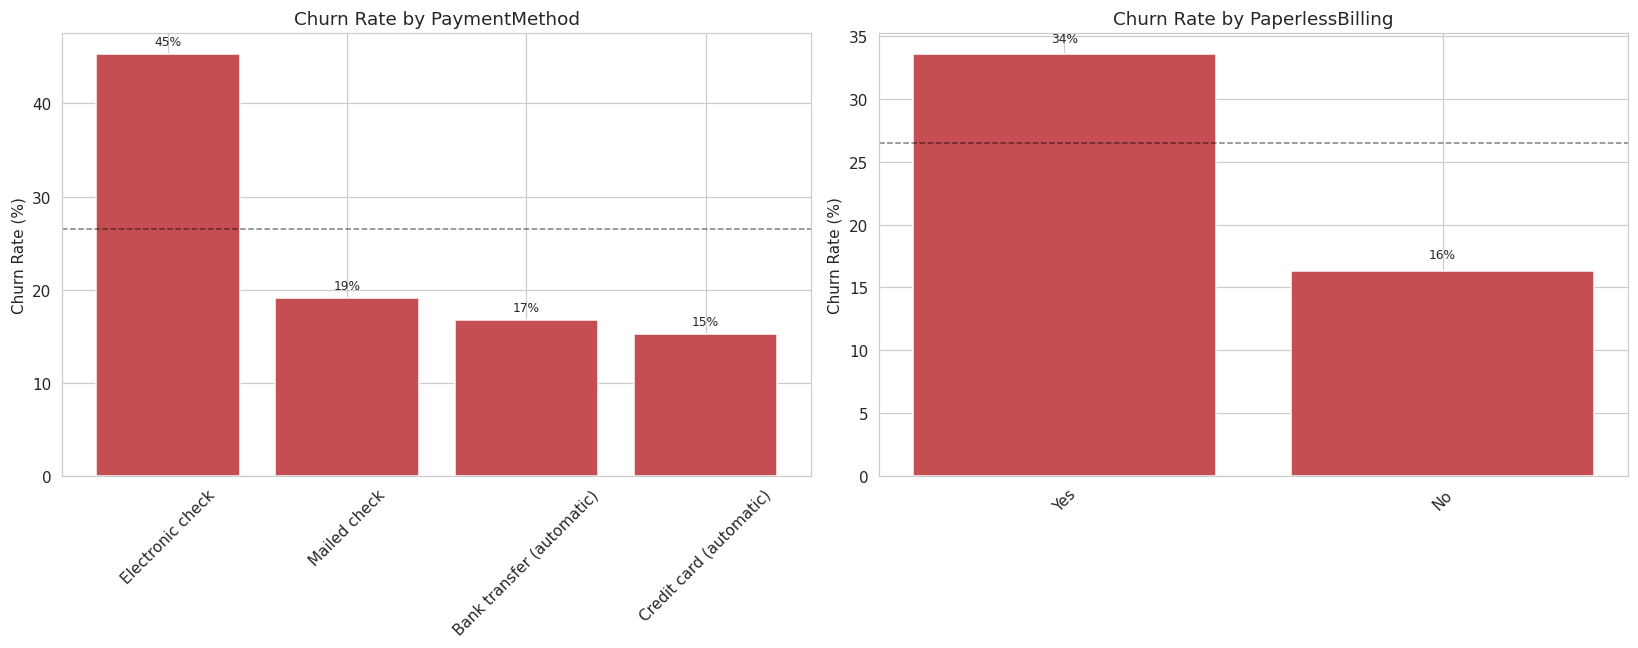

In [22]:
# Visualizing Churn Rate for Billing-Related Features

billing_features = ['PaymentMethod', 'PaperlessBilling']
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, col in zip(axes.flat, billing_features):
    rates = churn_rate_by_category(df_eda, col)
    bars = ax.bar(rates.index.astype(str), rates.values, color="#C44E52")
    ax.axhline(churn_rate * 100, color="black", linestyle="--", alpha=0.5, linewidth=1)
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate (%)")
    ax.tick_params(axis="x", rotation=45)
    for b, v in zip(bars, rates.values):
        ax.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.0f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

### Visualizing Churn Rate for Billing-Related Features

This cell generates two bar plots to examine the churn rate in relation to `PaymentMethod` and `PaperlessBilling`. These plots are essential for understanding how billing preferences and methods might correlate with customer churn.


**Visual Insights from the Plots:**
*   **PaymentMethod**: Customers using 'Electronic check' have a significantly higher churn rate (around 45%) compared to all other payment methods (which are in the 15-19% range). This is a very strong indicator and suggests that there might be issues associated with electronic checks, or that customers who prefer this method are inherently more prone to churn.
*   **PaperlessBilling**: Customers who opt for 'PaperlessBilling' ('Yes', ~34%) show a higher churn rate than those who do not ('No', ~16%). This suggests that while paperless billing is convenient, it might not foster the same level of loyalty or engagement as traditional billing methods, or it's a preference of a customer segment more inclined to churn.

These plots show that customers using 'Electronic check' have a significantly higher churn rate compared to other payment methods. Additionally, customers with 'PaperlessBilling' tend to churn more often than those without it. This suggests that the convenience of electronic transactions might be coupled with a lower barrier to switching providers, or perhaps these payment/billing methods are preferred by customer segments with higher churn risk.

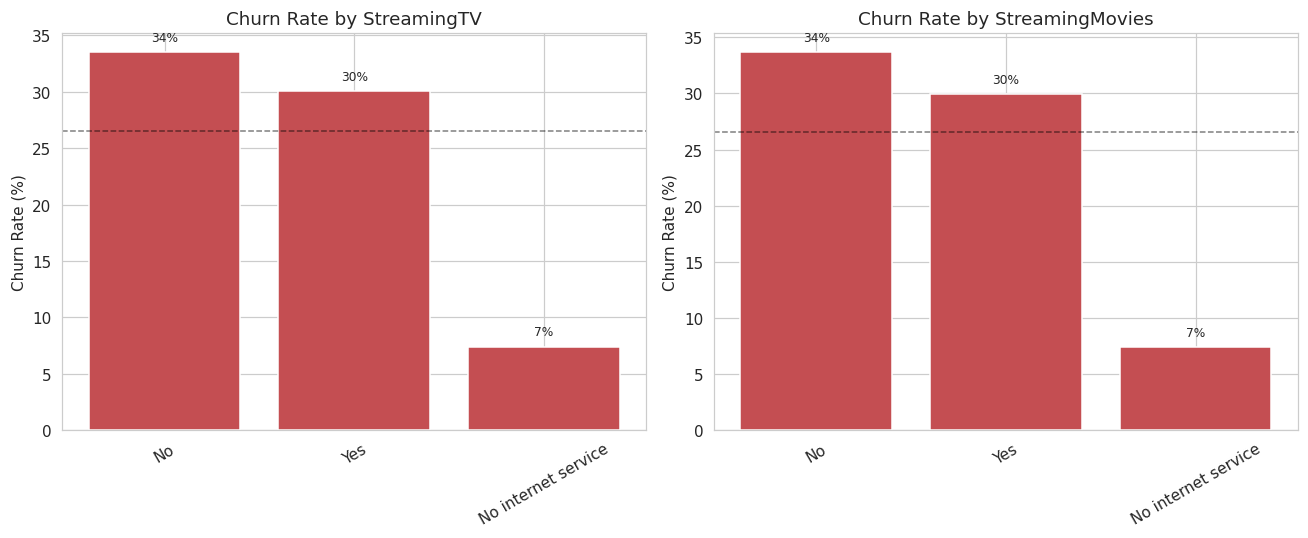

In [23]:
# Visualizing Churn Rate for Streaming Services

streaming_features = ['StreamingTV', 'StreamingMovies']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes.flat, streaming_features):
    rates = churn_rate_by_category(df_eda, col)
    bars = ax.bar(rates.index.astype(str), rates.values, color="#C44E52")
    ax.axhline(churn_rate * 100, color="black", linestyle="--", alpha=0.5, linewidth=1)
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate (%)")
    ax.tick_params(axis="x", rotation=30)
    for b, v in zip(bars, rates.values):
        ax.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.0f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

### Visualizing Churn Rate for Streaming Services

This cell generates two bar plots to examine the churn rate in relation to `StreamingTV` and `StreamingMovies`. These visualizations help to understand if the presence or absence of these streaming services has a notable impact on customer churn.

**Visual Insights from the Plots:**
*   **StreamingTV and StreamingMovies (No internet service)**: Customers who do not have internet service (and therefore no streaming services) consistently show the lowest churn rates (around 7%). This is expected, as they are not subject to the same internet-related dissatisfactions that might drive churn.
*   **StreamingTV and StreamingMovies (No vs. Yes)**: Among customers who *do* have internet service, there's a minor difference in churn rates. Customers who do *not* subscribe to `StreamingTV` or `StreamingMovies` tend to have slightly higher churn rates (around 34%) compared to those who *do* subscribe (around 30%). This small difference suggests that while streaming services might contribute slightly to retention, they are not as strong a churn driver or preventer as other factors like contract type or internet service quality.

The plots for StreamingTV and StreamingMovies show a similar pattern to other internet-related services: customers who do not have these services (often due to not having internet service at all) exhibit a lower churn rate compared to those who do. Among customers with internet service, there isn't a dramatic difference in churn based on whether they stream TV or movies, although those without the service might have a slightly higher churn than those with it, suggesting these services might contribute to retention for some segments.

In [24]:
# Num vs Num: correlation matrix

corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
corr_df = df_eda[corr_cols].copy()
corr_df["Churn_binary"] = (df_eda["Churn"] == "Yes").astype(int)

corr_matrix = corr_df.corr()
corr_matrix.round(3)


,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn_binary
tenure,1.000,0.248,0.826,0.017,-0.352
MonthlyCharges,0.248,1.000,0.651,0.220,0.193
TotalCharges,0.826,0.651,1.000,0.103,-0.198
SeniorCitizen,0.017,0.220,0.103,1.000,0.151
Churn_binary,-0.352,0.193,-0.198,0.151,1.000


Insight: These correlations are crucial for understanding potential multicollinearity among numerical features. The strong correlation between TotalCharges and tenure, and the moderate-strong correlation between TotalCharges and MonthlyCharges, confirm that TotalCharges is highly dependent on and can be largely explained by tenure and MonthlyCharges. This means TotalCharges is not an independent signal in the dataset but rather an accumulated effect of other features. In predictive modeling, this often suggests that including all three might introduce redundancy, and one might consider using only tenure and MonthlyCharges (or a derived feature) to avoid multicollinearity issues.

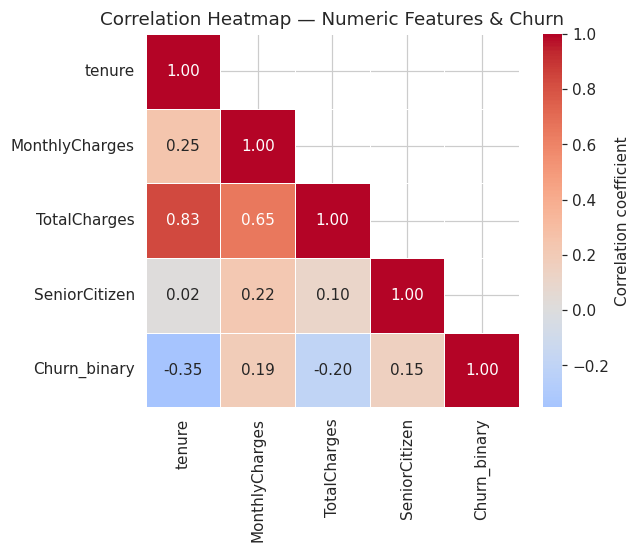

In [25]:
# Heatmap: color-coded matrix for quick pattern detection

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            mask=mask, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Correlation coefficient"})
ax.set_title("Correlation Heatmap — Numeric Features & Churn")
plt.tight_layout()
plt.show()


Insights from the Heatmap:

The heatmap visually confirms and summarizes the correlations discussed earlier:

TotalCharges vs. tenure (0.83): This shows a very strong positive correlation. As tenure increases, TotalCharges almost always increases. This is highly expected as TotalCharges is an accumulation over time.
TotalCharges vs. MonthlyCharges (0.65): A moderately strong positive correlation. Higher MonthlyCharges generally lead to higher TotalCharges, given a certain tenure.
tenure vs. MonthlyCharges (0.25): A weak positive correlation. There's a slight tendency for MonthlyCharges to increase with tenure, but it's not a strong relationship.
Churn_binary vs. tenure (-0.35): A moderate negative correlation. Customers with shorter tenure are more likely to churn.
Churn_binary vs. MonthlyCharges (0.19): A weak positive correlation. Customers with higher MonthlyCharges show a slightly increased likelihood of churning.
Churn_binary vs. TotalCharges (-0.20): A weak negative correlation. Customers with lower TotalCharges are slightly more likely to churn, reinforcing the tenure-churn relationship (lower total charges often mean shorter tenure).
SeniorCitizen correlations: SeniorCitizen has weak correlations with all other variables and Churn_binary. Its correlation with Churn_binary is 0.15, suggesting senior citizens are slightly more likely to churn, but it's not a major driver compared to other factors.
Overall Takeaway:

The heatmap provides a clear, at-a-glance view of multicollinearity (e.g., TotalCharges being highly correlated with tenure and MonthlyCharges) and the key drivers of Churn. tenure is the strongest individual predictor of churn among the numeric features, with a clear negative relationship (longer tenure means less churn).

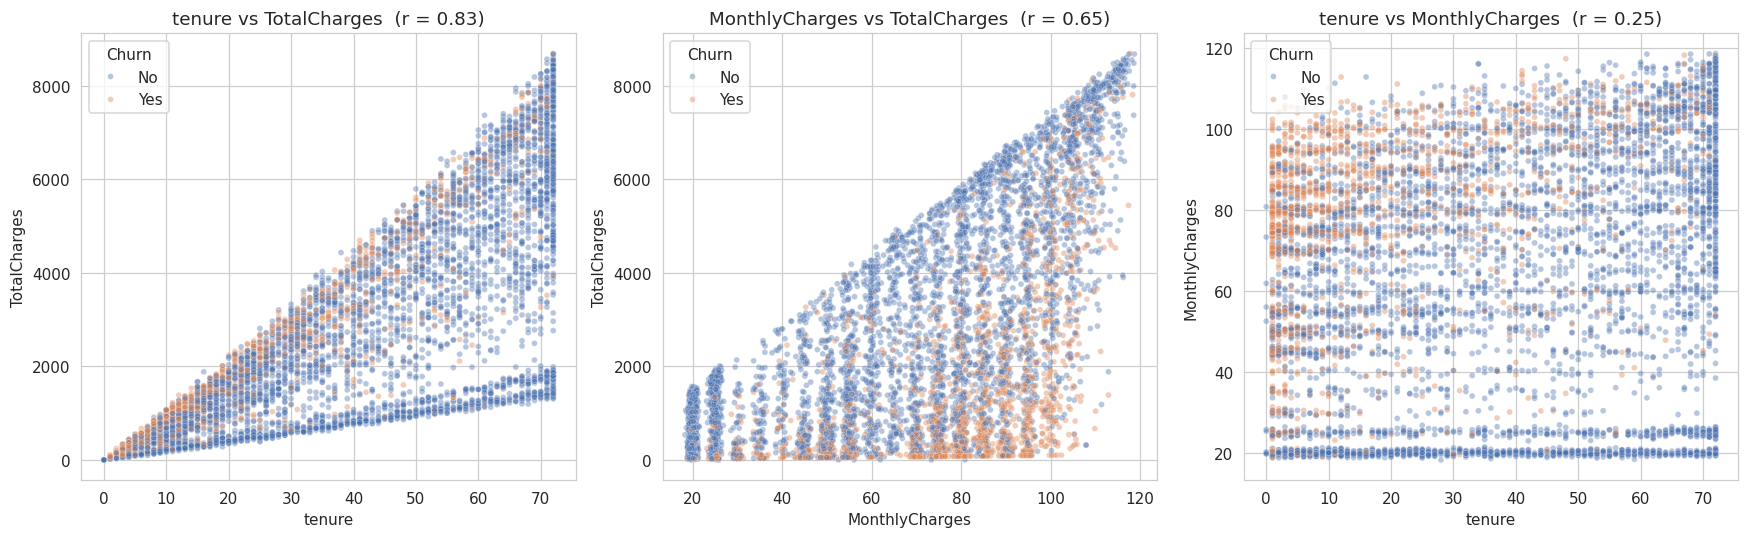

In [26]:
# Num vs Num: scatterplots for the strongest numeric pairs, colored by churn

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [("tenure", "TotalCharges"), ("MonthlyCharges", "TotalCharges"), ("tenure", "MonthlyCharges")]
for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(data=df_eda, x=x, y=y, hue="Churn", alpha=0.4, s=15,
                     palette=["#4C72B0", "#DD8452"], ax=ax)
    r = corr_matrix.loc[x, y]
    ax.set_title(f"{x} vs {y}  (r = {r:.2f})")
plt.tight_layout()
plt.show()


In [27]:
# Multicollinearity Check

print("TotalCharges vs tenure:         r =", round(corr_matrix.loc["TotalCharges","tenure"], 3), " -> STRONG")
print("TotalCharges vs MonthlyCharges: r =", round(corr_matrix.loc["TotalCharges","MonthlyCharges"], 3), " -> MODERATE-STRONG")
print("tenure vs MonthlyCharges:       r =", round(corr_matrix.loc["tenure","MonthlyCharges"], 3), " -> WEAK")

TotalCharges vs tenure:         r = 0.826  -> STRONG
TotalCharges vs MonthlyCharges: r = 0.651  -> MODERATE-STRONG
tenure vs MonthlyCharges:       r = 0.248  -> WEAK


Multicollinearity Check

The following lines print the Pearson correlation coefficients between specific pairs of numeric features and the binary 'Churn' variable. This helps to identify potential multicollinearity, which is when independent variables in a model are correlated with each other. High multicollinearity can make it difficult to interpret the individual impact of each variable on the target.

Multicollinearity finding: `TotalCharges` is strongly correlated with
`tenure` (r = 0.83) and moderately correlated with `MonthlyCharges`
(r = 0.65) — which makes sense, since `TotalCharges` is essentially the accumulation of monthly billing over time. It is *not* an independent
signal.


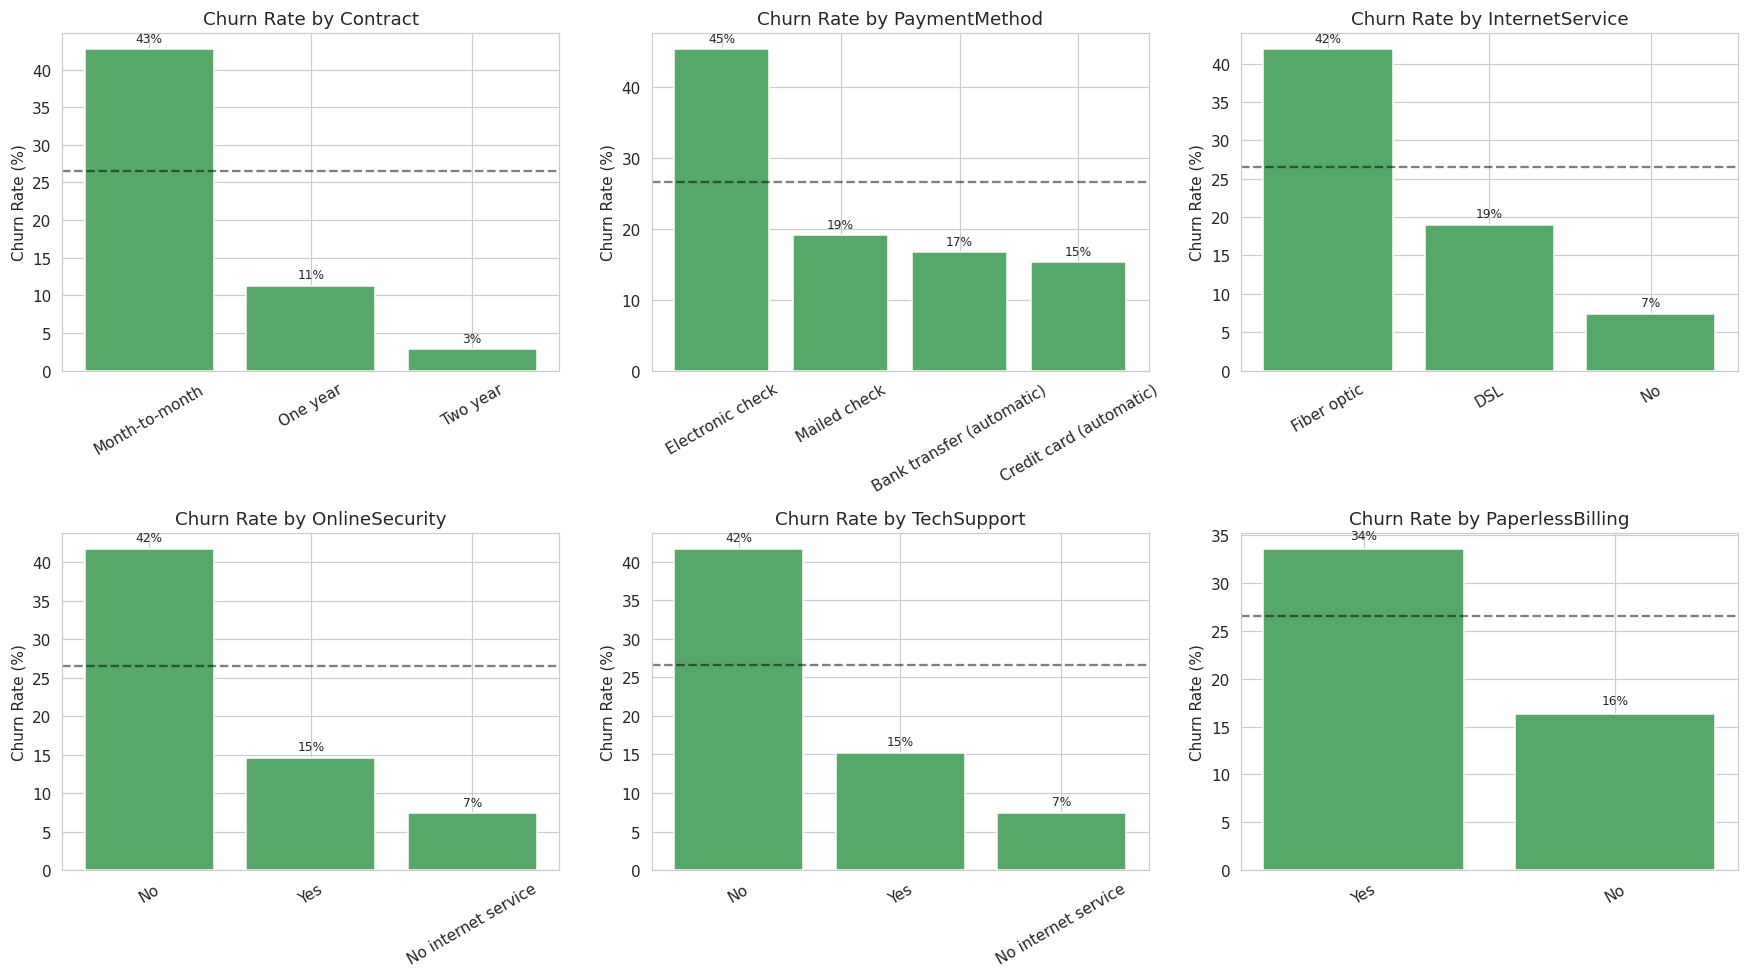

In [28]:
# Visualizing Churn Rate for Key Business-Relevant Categorical Features

cat_focus = ["Contract", "PaymentMethod", "InternetService",
             "OnlineSecurity", "TechSupport", "PaperlessBilling"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, cat_focus):
    rates = churn_rate_by_category(df_eda, col)
    bars = ax.bar(rates.index.astype(str), rates.values, color="#55A868")
    ax.axhline(churn_rate * 100, color="black", linestyle="--", alpha=0.5)
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate (%)")
    ax.tick_params(axis="x", rotation=30)
    for b, v in zip(bars, rates.values):
        ax.text(b.get_x()+b.get_width()/2, v+1, f"{v:.0f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.show()


### Visualizing Churn Rate for Key Business-Relevant Categorical Features

This cell generates a series of bar plots to visually represent the churn rate across categories for six categorical features deemed most business-relevant. This helps in understanding the granular impact of each category within these features on customer churn, using a green color palette for the bars.

**Key Insights from the Plots:**

*   **Contract**: Month-to-month contracts continue to show the highest churn rate (around 43%), significantly higher than one-year (11%) and two-year (3%) contracts. This emphasizes the importance of longer-term contracts for retention.

*   **PaymentMethod**: Customers using 'Electronic check' have a substantially higher churn rate (around 45%) compared to other payment methods (ranging from 15-19%). This suggests a potential area for intervention related to this payment type.

*   **InternetService**: 'Fiber optic' service users exhibit a high churn rate (around 42%), while customers with 'DSL' (19%) or 'No' internet service (7%) have much lower churn rates. This indicates potential dissatisfaction with fiber optic service quality or support.

*   **OnlineSecurity, TechSupport**: For both these services, customers who do *not* have the service (and have internet service) show a high churn rate (around 42%). In contrast, those who *do* have these services have much lower churn rates (around 15%). Customers with 'No internet service' consistently have the lowest churn.

*   **PaperlessBilling**: Customers who use 'PaperlessBilling' have a higher churn rate (34%) than those who don't (16%). This might imply that digital-first customers are more likely to churn, or that the paperless option is preferred by a segment with higher churn propensity.

These plots provide actionable insights by highlighting specific customer segments and service aspects that are strongly correlated with churn, guiding potential retention strategies.